# urOMT on a pyCERR `planC`

Unbalanced regularized Optimal Mass Transport (urOMT) recovers a **fluid transport** model (velocity + source) from longitudinal DCE-MRI scans. This notebook runs the full pipeline on a `planC` and stores the result on the plan container as `planC.urOMT` (a list of `UROMT` objects, like `planC.im`).

**Pipeline (ported from MATLAB urOMT `driver_RatBrain.m`):**
1. **Part 1** - DCE signal -> contrast concentration, ROI crop, smoothing.
2. **Part 2** - urOMT optimization (Gauss-Newton): per-interval velocity `u` & source `r`.
3. **Part 3** - Eulerian maps: speed, rate, Peclet, mean flux (`runEULA`).
4. **Part 4** - Lagrangian transport pathlines (`runGLAD`).
5. **Part 5** - visualization (inline below; interactive via napari / desktop GUI).

## 0. Use the local pyCERR

pyCERR is run **in place** from this working copy (the urOMT code lives only here), so the repo root must be on `sys.path`. The cell below does that automatically; run it first.

In [1]:
# --- Make the LOCAL pyCERR importable -------------------------------------
# pyCERR here is used in-place (not pip-installed), so the repo root (the
# folder containing `cerr/`) must be on sys.path. This walks up from the
# notebook location to find it and adds it -- so the notebook works whether you
# launched Jupyter from the repo root or from notebooks/.
#
# Alternatively, install it once (then this cell is unnecessary):
#     conda activate pycerr
#     cd <repo root>            # the folder containing setup.py / pyproject.toml
#     pip install -e .
import os, sys
_p = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_p, 'cerr')):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        break
    _p = os.path.dirname(_p)
import cerr
print('using cerr from:', os.path.dirname(cerr.__file__))

using cerr from: C:\software\pyCERR_master\pyCERR\cerr


## 1. Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import cerr.plan_container as pc
from cerr.uromt import runUROMTPipeline
from cerr.uromt.analyze import runEULA, runGLAD   # if you want to re-run parts 3-4
from cerr.uromt import viz

### 2. Load planC

In [ ]:
import numpy as np, matplotlib.pyplot as plt
import cerr.plan_container as pc
from cerr.uromt import runUROMTPipeline
from cerr.uromt import viz
from cerr.mri_metrics.dce_mri import getScanOrder

planC = pc.loadPlanCFromPkl(r'C:\software\urOMT\test_data\BC1V1_planC.pkl')

# Order scans by acquisition time (planC scan order may not be temporal), then
# run Parts 1-4 and store the run on planC.urOMT; returns its index.
idx = runUROMTPipeline(planC, scanNumV=getScanOrder(planC),
                       structNum=0, settingsFile=None, analyze=True)

run = planC.urOMT[idx]
res, Eul, Lag = run.UROMTResult, run.UROMTEulerian, run.UROMTLagrangian

## 3. Configure & run

**Timepoint order matters.** urOMT treats the scan list as the timepoint sequence, but scans in a `planC` are not necessarily stored in temporal order. `cerr.mri_metrics.dce_mri.getScanOrder(planC)` returns the scan indices ordered by **acquisition time** (DICOM AcquisitionDate/Time), and we pass that as `scanNumV`. (On the demo data the chronological order is `[0, 1, 12, 21, 22, ...]`, i.e. timepoint 2 is actually scan #12.)

Model/algorithm settings come from a JSON file. This demo uses **`notebooks/urOMT_fast_settings.json`** (a few time points, `nt=4`, `maxUiter=3`) so the solve finishes in well under a minute. For real analysis, pass `settingsFile=None` to use the bundled production defaults (`cerr/uromt/settings/uromt_model_settings.json`: more time points, `nt=10`, `maxUiter=6`), or copy that file, edit it (e.g. `T10`, `r1`, `alpha`, `beta`, the `time` window, `solver`), and pass its path.

Data settings (voxel spacing, ROI mask, TR/flip angle) are always read from `planC`. The run is stored on `planC.urOMT` and its index is returned.

In [3]:
from cerr.mri_metrics.dce_mri import getScanOrder

planC = pc.loadPlanCFromPkl(r'C:\software\urOMT\test_data\BC1V1_planC.pkl')

# Scans in a planC may NOT be stored in temporal order (e.g. lexical series
# order). Order them by acquisition time first -- urOMT treats the scan list as
# the timepoint sequence, so the order must be chronological.
scanNumV = getScanOrder(planC)
structNum = 0                             # ROI structure
print('temporal scan order:', scanNumV)

# Fast demo settings (few time points, low nt/maxUiter) -> finishes in well
# under a minute. Set settingsFile=None for the bundled production defaults
# (more time points, nt=10, maxUiter=6), or point at your own edited JSON.
_repo = os.path.dirname(os.path.dirname(cerr.__file__))
settingsFile = os.path.join(_repo, 'notebooks', 'urOMT_fast_settings.json')

# Runs Parts 1-4 and stores the run on planC.urOMT; returns its index.
idx = runUROMTPipeline(planC, scanNumV, structNum=structNum,
                       settingsFile=settingsFile, analyze=True)
print('stored as planC.urOMT[%d]' % idx)

temporal scan order: [0, 1, 12, 21, 22, 23, 24, 25, 26, 27, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20]
stored as planC.urOMT[0]


## 3. Configure & run

Model/algorithm settings come from a JSON file (the bundled default is used when `settingsFile=None`). Data settings (voxel spacing, mask, TR/flip angle) are read from `planC`. To customize (e.g. `T10`, `r1`, `alpha`, `beta`, the time-point selection, or `solver`), copy `cerr/uromt/settings/uromt_model_settings.json`, edit it, and pass its path.

Below we run on **all** scans as time points using structure 0 as the ROI. The solve is the expensive step (a few minutes on a typical ROI); reduce the time points via the `time` block in a settings file to speed it up.

In [ ]:
from cerr.mri_metrics.dce_mri import getScanOrder

# order scans by acquisition time (planC scan order may not be temporal)
scanNumV = getScanOrder(planC)
structNum = 0                             # ROI structure

# Runs Parts 1-4 and stores the run on planC.urOMT; returns its index.
idx = runUROMTPipeline(planC, scanNumV, structNum=structNum,
                       settingsFile=None, analyze=True)
print('stored as planC.urOMT[%d]' % idx)

## 4. Access the stored run

Everything (inputs **and** outputs) lives on `planC.urOMT[idx]`:
- `UROMTSetup` - settings, scan/ROI indices, concentration frames, mask/bbox/spacing
- `UROMTResult` - per-interval `u` (3,N,nt), `r` (N,nt), `rho`, `gamma`
- `UROMTEulerian` - `speed`/`rate`/`peclet`/`flux` maps (+ 3-D reshapes)
- `UROMTLagrangian` - `SL` pathlines, `sstream`/`pestream`, `disp`/`displen`

In [4]:
run = planC.urOMT[idx]
res, Eul, Lag = run.UROMTResult, run.UROMTEulerian, run.UROMTLagrangian
print('UID:', run.UROMTUID)
print('ROI grid:', res['n'], ' spacing(cm):', [round(s,3) for s in res['spacing']])
print('intervals:', len(res['u']))
for t, g in enumerate(res['gamma']):
    print('  interval %d: Gamma=%.4g  fit=%.4g' % (t+1, g['Gamma'], g['Gamma3']))
m = (np.asarray(res['mask'])>0).ravel(order='F')
print('Eulerian: mean speed=%.4f  mean Peclet=%.1f' % (Eul['speed'][m].mean(),
                                                       Eul['peclet'][m].mean()))
print('Lagrangian: %d pathlines, mean displacement=%.3f cm' %
      (len(Lag['SL']), Lag['displen'].mean() if len(Lag['displen']) else 0))

UID: UROMT.24062026.100348.765816.168
ROI grid: [40, 33, 25]  spacing(cm): [0.106, 0.106, 0.14]
intervals: 2
  interval 1: Gamma=11.88  fit=0.002376
  interval 2: Gamma=362.2  fit=0.07239
Eulerian: mean speed=0.0045  mean Peclet=0.5
Lagrangian: 42 pathlines, mean displacement=0.123 cm


## 5. Inline visualization (matplotlib)

### Eulerian mean-speed map + flux vectors on a central ROI slice

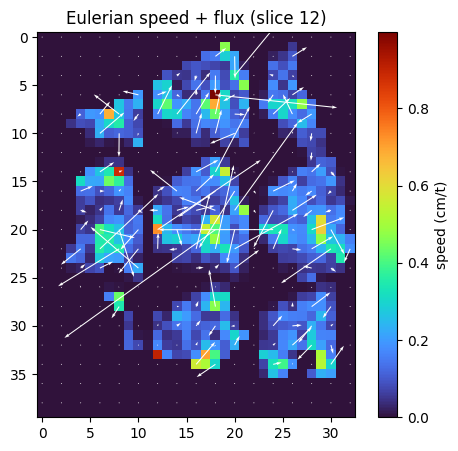

In [9]:
sp3 = Eul['speed3']
k = sp3.shape[2] // 2
f0 = Eul['flux'][0].reshape(Eul['n'], order='F')
f1 = Eul['flux'][1].reshape(Eul['n'], order='F')
yy, xx = np.mgrid[0:sp3.shape[0], 0:sp3.shape[1]]
step = max(1, sp3.shape[0]//20)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(sp3[:,:,k], cmap='turbo'); plt.colorbar(im, ax=ax, label='speed (cm/t)')
ax.quiver(xx[::step,::step], yy[::step,::step],
          f1[::step,::step,k], f0[::step,::step,k], color='w', scale_units='xy')
ax.set_title('Eulerian speed + flux (slice %d)' % k); plt.show()

### Lagrangian pathlines (axial projection) coloured by speed

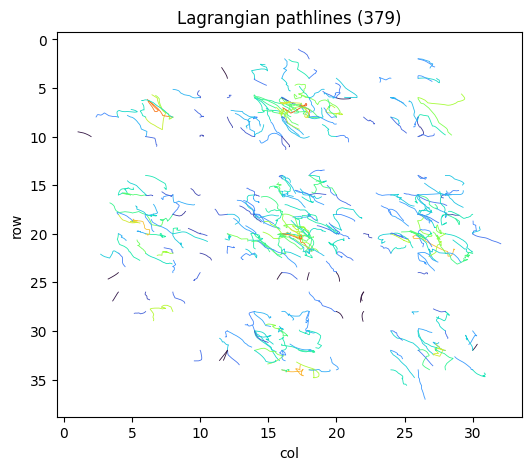

In [10]:
fig, ax = plt.subplots(figsize=(6,5))
for pl, sp in zip(Lag['SL'], Lag['sstream']):
    pl = np.asarray(pl)
    c = float(np.mean(sp)) if len(sp) else 0.0
    ax.plot(pl[:,1], pl[:,0], '-', lw=0.6,
            color=plt.cm.turbo(min(c/ (Lag['displen'].max()+1e-6), 1.0)))
ax.set_xlabel('col'); ax.set_ylabel('row'); ax.invert_yaxis()
ax.set_title('Lagrangian pathlines (%d)' % len(Lag['SL'])); plt.show()

## 6. Interactive viewing (napari / pyCERR desktop GUI)

The same results render as 3-D overlays. From a notebook/script with a display:

```python
viz.showVelocity(planC, res)                       # velocity vectors
viz.showEulerian(planC, Eul, field='speed')        # speed map + flux flowlines
viz.showLagrangian(planC, Lag, colorBy='speed')    # transport pathlines (Tracks)
```

In the **pyCERR desktop GUI**: *Tools -> urOMT*, pick the ROI and time points, **Run** (the run is stored on `planC.urOMT`), then **Show velocity / Eulerian / Pathlines**.

## 7. Persisting the results

`planC.urOMT` travels with the plan container (it is a normal instance attribute), so pickling the planC keeps every urOMT run (inputs + outputs) and `pc.loadPlanCFromPkl` restores them.

In [ ]:
import pickle
# with open(r'C:\path\to\planC_with_uromt.pkl', 'wb') as f:
#     pickle.dump(planC, f)
print('planC.urOMT now holds %d run(s)' % len(planC.urOMT))

In [5]:
%gui qt

from cerr.viewer.pycerr_gui import launch, show

viewer = show(planC)


C:\Users\aptea\Miniconda3\envs\pycerr\Lib\site-packages\matplotlib\quiver.py:649: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
C:\Users\aptea\Miniconda3\envs\pycerr\Lib\site-packages\matplotlib\quiver.py:649: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


In [12]:
settingsFile

'C:\\software\\pyCERR_master\\pyCERR\\notebooks\\urOMT_fast_settings.json'

C:\Users\aptea\Miniconda3\envs\pycerr\Lib\site-packages\napari\layers\tracks\tracks.py:643: UserWarning: Previous color_by key 'speed' not present in features. Falling back to track_id
  warn(
C:\Users\aptea\Miniconda3\envs\pycerr\Lib\site-packages\napari\layers\tracks\tracks.py:643: UserWarning: Previous color_by key 'speed' not present in features. Falling back to track_id
  warn(
C:\Users\aptea\Miniconda3\envs\pycerr\Lib\site-packages\ipykernel\eventloops.py:145: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  el.exec() if hasattr(el, "exec") else el.exec_()
